# Heart Disease Prediction using Machine Learning

## Objective
This project predicts whether a patient has heart disease based on medical attributes using a Logistic Regression model.

## Technologies Used
- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn

## Problem Type
Binary Classification (Heart Disease Detection)

## Dataset
UCI Heart Disease Dataset (CSV format)

In [24]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [26]:
df = pd.read_csv("heart_disease.csv")

print(df.head())
print(df.shape)
print(df.columns)

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0   0.0  1.0  2.0       3.0    4.0  5.0      6.0      7.0    8.0      9.0   
1  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
2  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
3  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
4  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   

   slope   ca thal  num  
0   10.0   11   12   13  
1    3.0  0.0  6.0    0  
2    2.0  3.0  3.0    2  
3    2.0  2.0  7.0    1  
4    3.0  0.0  3.0    0  
(304, 14)
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')


In [28]:
df = df.replace('?', np.nan)
df = df.apply(pd.to_numeric)
df = df.fillna(df.median())

In [29]:
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

print(df['target'].value_counts())

target
0    164
1    140
Name: count, dtype: int64


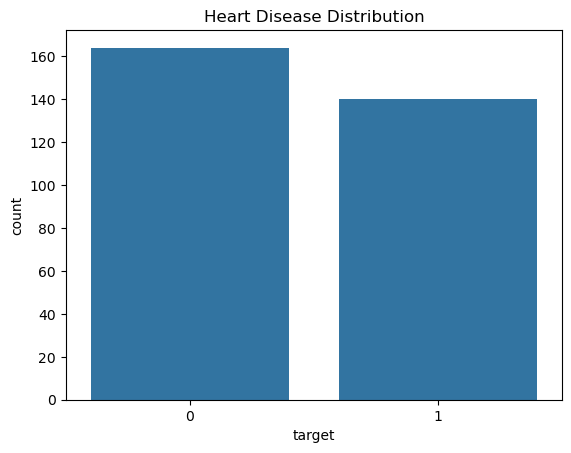

In [30]:
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

In [31]:
X = df.drop(['num', 'target'], axis=1)
y = df['target']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [34]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [35]:
y_pred = model.predict(X_test)

In [36]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8524590163934426

Confusion Matrix:
 [[26  3]
 [ 6 26]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.90      0.85        29
           1       0.90      0.81      0.85        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.86      0.85      0.85        61



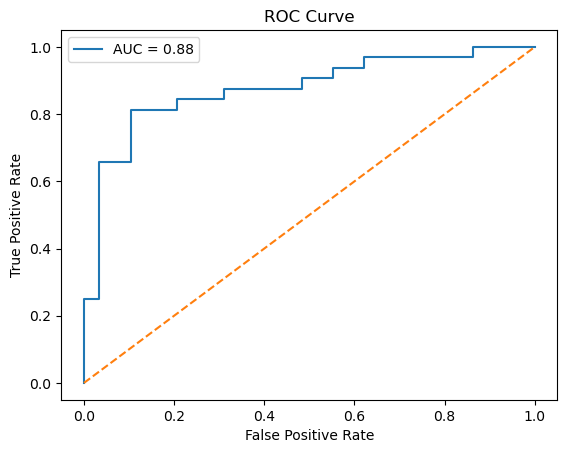

In [37]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

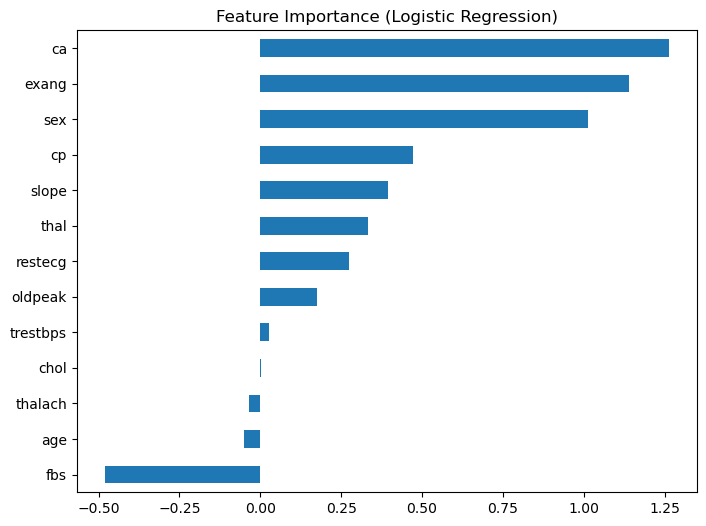

In [38]:
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance (Logistic Regression)")
plt.show()

In [39]:
print("MODEL SUMMARY")
print("------------------")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC Score:", roc_auc)

MODEL SUMMARY
------------------
Accuracy: 0.8524590163934426
AUC Score: 0.875


# Final Insights

- Logistic Regression was used for binary classification.
- The dataset was cleaned by handling missing values and converting categorical noise.
- The model was evaluated using accuracy, confusion matrix, and ROC curve.
- Feature analysis helped understand key medical indicators affecting heart disease.
- The model provides a baseline predictive system for early disease detection.